In [24]:
from google.colab import drive
drive.mount('/content/drive') 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [43]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

dataset_path = '/kaggle/input/skin-cancer-mnist-ham10000'
csv_path = os.path.join(dataset_path, 'HAM10000_metadata.csv')

df = pd.read_csv(csv_path)

mapeamento_lesoes = {
    'nv': 'Nevo Melanocitico (Benigno)',
    'mel': 'Melanoma (Maligno)',
    'bcc': 'Carcinoma Basocelular (Maligno)',  
    'akiec': 'Queratose Actinica (Pre-Maligno)',
    'bkl': 'Queratose Benigna (Benigno)',
    'df': 'Dermatofibroma (Benigno)',
    'vasc': 'Lesao Vascular (Benigno)'
}

df['dx'] = df['dx'].map(mapeamento_lesoes)

def caminho_da_imagem(image_id):
    nome_arquivo = f"{image_id}.jpg"
    caminho_part1 = os.path.join(dataset_path, 'ham10000_images_part_1', nome_arquivo)
    if os.path.exists(caminho_part1):
        return caminho_part1
    return os.path.join(dataset_path, 'ham10000_images_part_2', nome_arquivo)

df['image_path'] = df['image_id'].apply(caminho_da_imagem)
df['label_idx'] = pd.Categorical(df['dx']).codes

train_df, val_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df['label_idx'])
val_df, test_df = train_test_split(val_df, test_size=0.4, random_state=42, stratify=val_df['label_idx'])

maior_classe = df['dx'].value_counts().index[0]
print(f"• Proporção no Treino:    {(train_df['dx'] == maior_classe).mean():.2%}")
print(f"• Proporção na Validação: {(val_df['dx'] == maior_classe).mean():.2%}")
print(f"• Proporção no Teste:     {(test_df['dx'] == maior_classe).mean():.2%}")


• Proporção no Treino:    66.95%
• Proporção na Validação: 66.96%
• Proporção no Teste:     66.94%


In [44]:
import tensorflow as tf

def carregar_e_processar_classificacao(caminho_img, label):

    img_raw = tf.io.read_file(caminho_img)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    
    return img, label

batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label_idx'].values))
val_dataset = val_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)


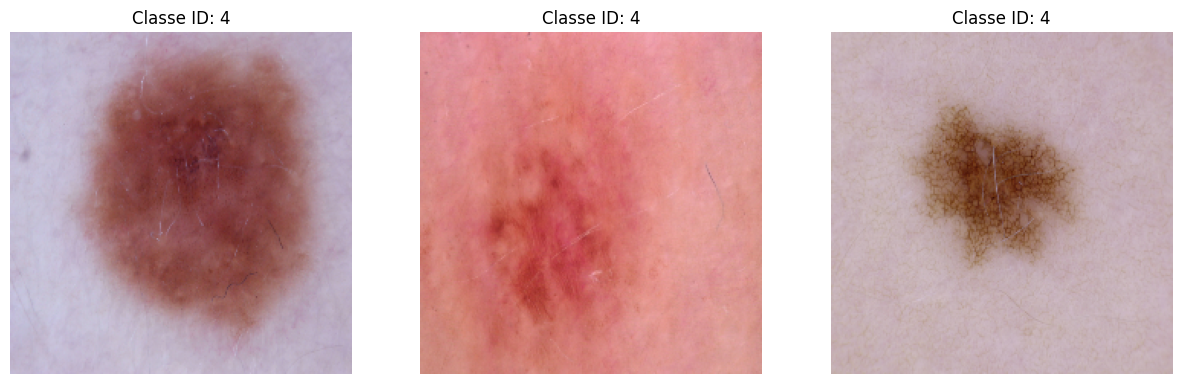

In [47]:
import matplotlib.pyplot as plt

for imagens_lote, labels_lote in train_dataset.take(1):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    
    for i in range(3):

        axes[i].imshow(imagens_lote[i].numpy())
        

        classe_id = int(labels_lote[i])
        axes[i].set_title(f"Classe ID: {classe_id}")
        
        axes[i].axis('off')
        
    plt.show()

In [48]:
from tensorflow.keras import layers, models


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


base_model.trainable = False


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), 
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4), 
    layers.Dense(7, activation='softmax') 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.6364 - loss: 1.2418

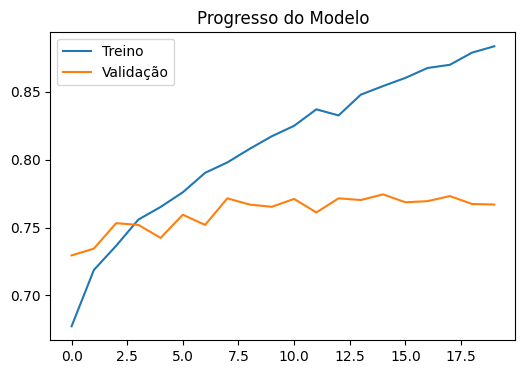

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.title('Progresso do Modelo')
plt.legend()
plt.show()

In [ ]:

train_df = pd.concat([train_df, val_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_idx'].values))
test_dataset = test_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


model.fit(train_dataset, epochs=3)

Epoch 1/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.8319 - loss: 0.4885
Epoch 2/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step - accuracy: 0.8421 - loss: 0.4527
Epoch 3/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step - accuracy: 0.8540 - loss: 0.4174


51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step


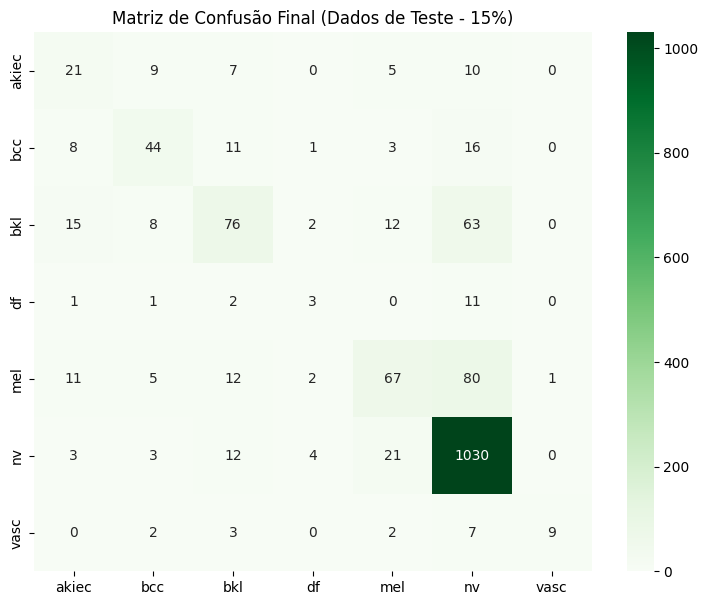

              precision    recall  f1-score   support

       akiec       0.36      0.40      0.38        52
         bcc       0.61      0.53      0.57        83
         bkl       0.62      0.43      0.51       176
          df       0.25      0.17      0.20        18
         mel       0.61      0.38      0.47       178
          nv       0.85      0.96      0.90      1073
        vasc       0.90      0.39      0.55        23

    accuracy                           0.78      1603
   macro avg       0.60      0.47      0.51      1603
weighted avg       0.76      0.78      0.76      1603



In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)

classes_nomes = pd.Categorical(df['dx']).categories.tolist()
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão Final (Dados de Teste - 15%)')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes_nomes))

Classe Real: nv


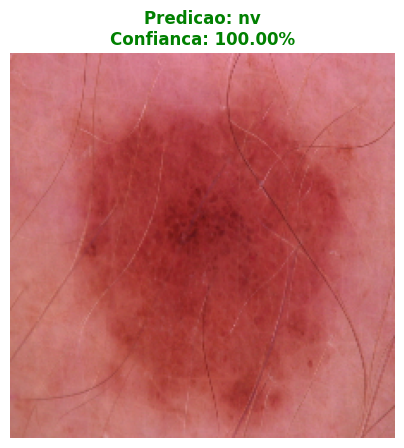

In [ ]:
def predizer_lesao(caminho_imagem_nova, modelo_treinado, lista_classes):
    
    img_raw = tf.io.read_file(caminho_imagem_nova)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0 
    
    img_lote = tf.expand_dims(img, axis=0)
    

    predicoes = modelo_treinado.predict(img_lote, verbose=0)
    
    indice_vencedor = np.argmax(predicoes[0])
    classe_vencedora = lista_classes[indice_vencedor]
    confianca = predicoes[0][indice_vencedor] * 100
    

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    
    
    if "Maligno" in classe_vencedora:
        cor_titulo = 'red'
    elif "Pre-Maligno" in classe_vencedora:
        cor_titulo = 'orange'
    else:
        cor_titulo = 'green'
        
    plt.title(f"Predicao: {classe_vencedora}\nConfianca: {confianca:.2f}%", 
              color=cor_titulo, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    return classe_vencedora, confianca


test = test_df['image_path'].iloc[3] 
real = test_df['dx'].iloc[3]


classes_nomes = pd.Categorical(df['dx']).categories.tolist()

print(f"Classe Real: {real}")

classe_prevista, certeza = predizer_lesao(test, model, classes_nomes)